# Debiasing Facial Detection Systems

Consider the task of facial detection: given an image, is it a face or not? It sounds trivial, yet this seemingly simple task suffers from significant **algorithmic bias** across demographics: models that work great on the faces they saw most often during training, and much worse on everyone else.

In this lab we tackle the problem head on. First we train a standard CNN for facial detection and measure how its accuracy changes across demographics. Then we build a **DB-VAE (debiasing variational autoencoder)**, a model that learns the **latent structure** of the face dataset on its own and uses it to **re-sample the training data adaptively**, giving rare faces more weight during training. Finally, we compare the two models and check whether the debiasing actually worked.

## Running this notebook on Kaggle

This notebook is designed to run on **Kaggle**, which gives us a free GPU and a clean way to store API keys. To set it up:

1. Create a new Notebook on [Kaggle](https://www.kaggle.com/code) and import this file (File > Import Notebook);
2. In the notebook settings, set **Accelerator** to a GPU (for example a T4 or P100) and make sure **Internet** is enabled;
3. Create a free account on [Comet](https://www.comet.com), which we will use to track our experiments, and copy your **API key** from your account settings;
4. Back on Kaggle, open **Add-ons > Secrets**, create a secret with label `COMET_API_KEY`, paste your key as the value, and attach it to this notebook.

The key is read through `kaggle_secrets`, so it never appears in the code. If you run this elsewhere (Colab, local machine), just replace that block with your own way of loading the key.

One note on dependencies: the `mitdeeplearning` package is a small utility library from the open MIT deep learning course. Here we use it to download the face datasets and for a few plotting helpers.

In [2]:
!pip install comet_ml --quiet
import comet_ml

from kaggle_secrets import UserSecretsClient
user_secrets = UserSecretsClient()
COMET_API_KEY = user_secrets.get_secret("COMET_API_KEY")
assert COMET_API_KEY != "", "Please insert your Comet API Key"

# utility library, used here for the dataset loaders and plotting helpers
!pip install mitdeeplearning --quiet
import mitdeeplearning as mdl

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 796.6/796.6 kB 16.8 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 59.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 38.9 MB/s eta 0:00:0000:0100:01
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 156.8/156.8 kB 12.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.9/40.9 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 80.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.0/71.0 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.2/20.2 MB 83.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 86.4 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 667.5/667.5 kB 25.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.7/99.7 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.0/345.0 kB 

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


In [3]:
import os
import random
import IPython
import functools
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
from pathlib import Path

# Import torch
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torch.backends.cudnn as cudnn


# Check that we are using a GPU: if not, enable the GPU
# accelerator from the Kaggle notebook settings
if torch.cuda.is_available():
    device = torch.device("cuda")
    cudnn.benchmark = True
else:
    raise ValueError("GPU is not available. Enable the GPU accelerator in the Kaggle notebook settings.")

## The datasets

We will use three datasets. To train the facial detection models we need **positive examples** (faces) and **negative examples** (things that are not faces). To evaluate them, we need a **test dataset with balanced representation** across the demographics we care about, because that is exactly where bias would hide. We will consider **skin tone** and **gender**.

- **Positive training data**: the CelebA dataset, a large-scale collection (over 200K images) of celebrity faces;
- **Negative training data**: images from ImageNet, taken from a variety of non-human categories;
- **Test data**: face images balanced across four groups, labeled by gender and by skin tone according to the **Fitzpatrick scale** ("Lighter" or "Darker").

Let's start by importing the training data.

In [4]:
CACHE_DIR = Path.home() / ".cache" / "mitdeeplearning"
CACHE_DIR.mkdir(parents=True, exist_ok=True)
# Get the training data: both images from CelebA and ImageNet
path_to_training_data = CACHE_DIR.joinpath("train_face.h5")

# Create a simple check to avoid re-downloading
if path_to_training_data.is_file():
    print(f"Using cached training data from {path_to_training_data}")
else:
    print(f"Downloading training data to {path_to_training_data}")
    url = "https://www.dropbox.com/s/hlz8atheyozp1yx/train_face.h5?dl=1"
    torch.hub.download_url_to_file(url, path_to_training_data)

# Instantiate a TrainingDatasetLoader using the downloaded dataset
channels_last = False
loader = mdl.lab2.TrainingDatasetLoader(
    path_to_training_data, channels_last=channels_last
)

100%|██████████| 1.18G/1.18G [00:11<00:00, 108MB/s] 

Opening /root/.cache/mitdeeplearning/train_face.h5
Loading data into memory...


Let's check the size of the training dataset and grab a batch of 100 images with their labels. Play around with the sliders below to display faces and non-faces from the training data and get a feel for what the model will see.

In [5]:
number_of_training_examples = loader.get_train_size()
(images, labels) = loader.get_batch(100)
B, C, H, W = images.shape

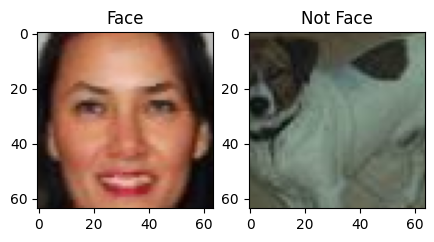

In [6]:
### Examining the CelebA training dataset ###

# @title Change the sliders to look at positive and negative training examples! { run: "auto" }

face_images = images[np.where(labels == 1)[0]].transpose(0, 2, 3, 1)
not_face_images = images[np.where(labels == 0)[0]].transpose(0, 2, 3, 1)

idx_face = 23  # @param {type:"slider", min:0, max:50, step:1}
idx_not_face = 9  # @param {type:"slider", min:0, max:50, step:1}

plt.figure(figsize=(5, 5))
plt.subplot(1, 2, 1)
plt.imshow(face_images[idx_face])
plt.title("Face")
plt.grid(False)

plt.subplot(1, 2, 2)
plt.imshow(not_face_images[idx_not_face])
plt.title("Not Face")
plt.grid(False)

### Thinking about bias

Remember the plan: we train on the large, well-curated CelebA dataset (plus ImageNet negatives), then we evaluate on an independent, balanced test set. The goal is a model that reaches high accuracy **across all demographics**, showing no hidden bias.

But what does "biased" mean, precisely? To formalize it we need the concept of **latent variables**: variables that define the dataset but are not explicitly observed (skin tone, pose, presence of hats or glasses, and so on). We use the term **latent space** for the probability distributions of these variables. Putting it together: we **consider a classifier biased if its decision changes after it sees some additional latent features**.

## A baseline: standard CNN for facial detection

First we define and train a CNN on the facial classification task and measure its accuracy: this will be the baseline our debiased model has to beat. The architecture is fairly standard: a series of convolutional layers with batch normalization, followed by two fully connected layers that flatten the convolutional output and produce the class prediction.

Training relies on PyTorch's automatic differentiation (`torch.autograd`), through the usual `loss.backward()` and `optimizer.step()` calls.

In [7]:
### Define the CNN model ###

n_filters = 12  # base number of convolutional filters
in_channels = images.shape[1]

def make_standard_classifier(n_outputs):
  # Start by first defining a convolutional block
  class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, stride, padding=0):
        super().__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size, stride, padding)
        self.relu = nn.ReLU(inplace=True)
        self.bn = nn.BatchNorm2d(out_channels)

    def forward(self, x):
        x = self.conv(x)
        x = self.relu(x)
        x = self.bn(x)
        return x

  # now use the block to define the classifier
  model = nn.Sequential(
      ConvBlock(in_channels, n_filters, kernel_size=5, stride=2, padding=2),
      ConvBlock(n_filters, 2*n_filters, kernel_size=5, stride=2, padding=2),
      ConvBlock(2*n_filters, 4*n_filters, kernel_size=3, stride=2, padding=1),
      ConvBlock(4*n_filters, 6*n_filters, kernel_size=3, stride=2, padding=1),
      nn.Flatten(),
      nn.Linear(H // 16 * W // 16 * 6 * n_filters, 512),
      nn.ReLU(inplace=True),
      nn.Linear(512, n_outputs),
  )

  return model.to(device)
    
# call the function to instantiate a classifier model
standard_classifier = make_standard_classifier(n_outputs=1)
print(standard_classifier)

Sequential(
  (0): ConvBlock(
    (conv): Conv2d(3, 12, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2))
    (relu): ReLU(inplace=True)
    (bn): BatchNorm2d(12, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (1): ConvBlock(
    (conv): Conv2d(12, 24, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2))
    (relu): ReLU(inplace=True)
    (bn): BatchNorm2d(24, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (2): ConvBlock(
    (conv): Conv2d(24, 48, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (relu): ReLU(inplace=True)
    (bn): BatchNorm2d(48, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (3): ConvBlock(
    (conv): Conv2d(48, 72, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (relu): ReLU(inplace=True)
    (bn): BatchNorm2d(72, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (4): Flatten(start_dim=1, end_dim=-1)
  (5): Linear(in_features=1152, out_features=512, bias=True)
  (6

In [8]:
### Create a Comet experiment to track our training run ###
def create_experiment(project_name, params):
    # end any prior experiments
    if "experiment" in locals():
        experiment.end()

    # initiate the comet experiment for tracking
    experiment = comet_ml.Experiment(api_key=COMET_API_KEY, project_name=project_name)
    # log our hyperparameters, defined above, to the experiment
    for param, value in params.items():
        experiment.log_parameter(param, value)
    experiment.flush()

    return experiment

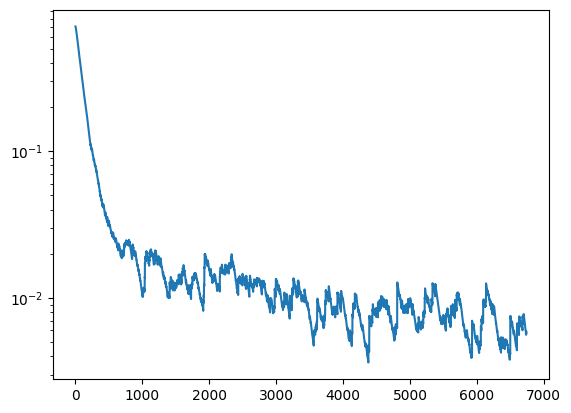

100%|██████████| 3434/3434 [00:31<00:00, 108.75it/s]
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO: Comet.ml Experiment Summary
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO:   Data:
COMET INFO:     display_summary_level : 1
COMET INFO:     name                  : recent_meadowlark_2828
COMET INFO:     url                   : https://www.comet.com/salvatore-borda/6s191-lab2-part2-cnn/377f27e957db4de4a72e3eeabcf9e171
COMET INFO:   Metrics [count] (min, max):
COMET INFO:     loss [7555] : (3.963881454183138e-07, 0.7081501483917236)
COMET INFO:   Parameters:
COMET INFO:     batch_size    : 32
COMET INFO:     learning_rate : 0.0005
COMET INFO:     num_epochs    : 2
COMET INFO:   Uploads:
COMET INFO:     environment details : 1
COMET INFO:     filename            : 1
COMET INFO:     installed packages  : 1
COMET INFO:     notebook            : 1
COMET INFO:     o

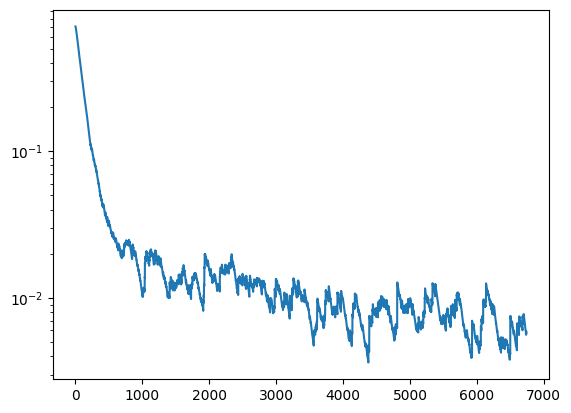

In [9]:
### Train the standard CNN ###
loss_fn = nn.BCEWithLogitsLoss()
# Training hyperparameters
params = dict(
    batch_size=32,
    num_epochs=2,  # keep small to run faster
    learning_rate=5e-4,
)

experiment = create_experiment("debiasing-facial-detection-cnn", params)

optimizer = optim.Adam(
    standard_classifier.parameters(), lr=params["learning_rate"]
)  # define our optimizer
loss_history = mdl.util.LossHistory(smoothing_factor=0.99)  # to record loss evolution
plotter = mdl.util.PeriodicPlotter(sec=2, scale="semilogy")
if hasattr(tqdm, "_instances"):
    tqdm._instances.clear()  # clear if it exists

# set the model to train mode
standard_classifier.train()


def standard_train_step(x, y):
    x = torch.from_numpy(x).float().to(device)
    y = torch.from_numpy(y).float().to(device)

    # clear the gradients
    optimizer.zero_grad()

    # feed the images into the model
    logits = standard_classifier(x)
    # Compute the loss
    loss = loss_fn(logits, y)

    # Backpropagation
    loss.backward()
    optimizer.step()

    return loss


# The training loop!
step = 0
for epoch in range(params["num_epochs"]):
    for idx in tqdm(range(loader.get_train_size() // params["batch_size"])):
        # Grab a batch of training data and propagate through the network
        x, y = loader.get_batch(params["batch_size"])
        loss = standard_train_step(x, y)
        loss_value = loss.detach().cpu().numpy()

        # Record the loss and plot the evolution of the loss as a function of training
        loss_history.append(loss_value)
        plotter.plot(loss_history.get())

        experiment.log_metric("loss", loss_value, step=step)
        step += 1

experiment.end()


Let's evaluate the trained CNN, starting from its accuracy on (a subset of) the training data itself.

In [10]:
### Evaluation of standard CNN ###

# set the model to eval mode
standard_classifier.eval()

# TRAINING DATA
# Evaluate on a subset of CelebA+Imagenet
(batch_x, batch_y) = loader.get_batch(5000)
batch_x = torch.from_numpy(batch_x).float().to(device)
batch_y = torch.from_numpy(batch_y).float().to(device)

with torch.inference_mode():
    y_pred_logits = standard_classifier(batch_x)
    y_pred_standard = torch.round(torch.sigmoid(y_pred_logits))
    acc_standard = torch.mean((batch_y == y_pred_standard).float())

print(
    "Standard CNN accuracy on (potentially biased) training set: {:.4f}".format(
        acc_standard.item()
    )
)

Standard CNN accuracy on (potentially biased) training set: 0.9986


We will also evaluate the network on an independent test dataset with faces never seen during training, measuring the classification accuracy across four demographics based on the Fitzpatrick skin scale and sex-based labels: dark-skinned male, dark-skinned female, light-skinned male, and light-skinned female.

Let's take a look at some sample faces from the test set.

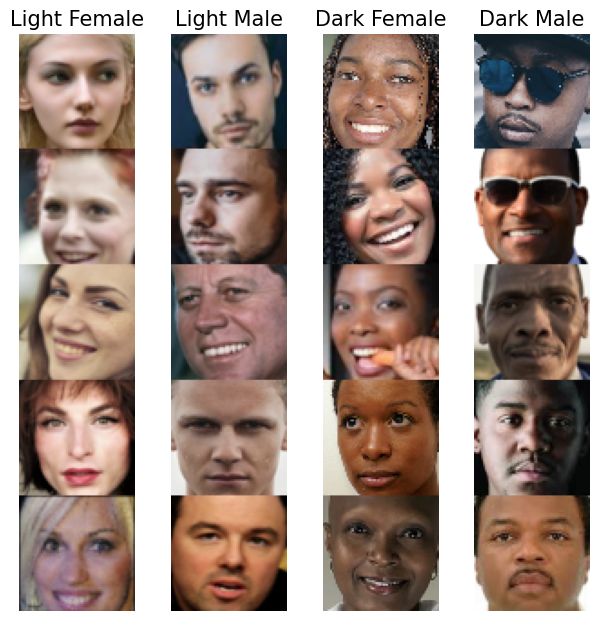

In [11]:
### Load test dataset and plot examples ###

test_faces = mdl.lab2.get_test_faces(channels_last=channels_last)
keys = ["Light Female", "Light Male", "Dark Female", "Dark Male"]

fig, axs = plt.subplots(1, len(keys), figsize=(7.5, 7.5))
for i, (group, key) in enumerate(zip(test_faces, keys)):
    axs[i].imshow(np.hstack(group).transpose(1, 2, 0))
    axs[i].set_title(key, fontsize=15)
    axs[i].axis("off")

Now let's evaluate the probability that each of these demographics gets classified as a face by the standard CNN we just trained.

Text(0.5, 1.0, 'Standard classifier predictions')

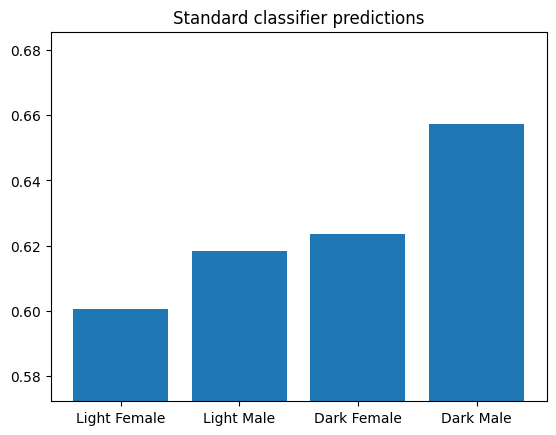

In [12]:
### Evaluate the standard CNN on the test data ###

standard_classifier_probs_list = []  # store each demographic's probabilities

with torch.inference_mode():
    for x in test_faces:
        x = torch.from_numpy(np.array(x, dtype=np.float32)).to(device)
        logits = standard_classifier(x)  # [B, 1]
        probs = torch.sigmoid(logits)  # [B, 1]
        probs = torch.squeeze(probs, dim=-1)  # shape [B]
        standard_classifier_probs_list.append(probs.cpu().numpy())

standard_classifier_probs = np.stack(standard_classifier_probs_list, axis=0)


# Plot the prediction accuracies per demographic
xx = range(len(keys))
yy = standard_classifier_probs.mean(axis=1)  # shape [D]
plt.bar(xx, yy)
plt.xticks(xx, keys)
plt.ylim(max(0, yy.min() - np.ptp(yy) / 2.0), yy.max() + np.ptp(yy) / 2.0)
plt.title("Standard classifier predictions")

Take a look at the accuracies of this first model across the four groups. What do you observe? Would you call this model biased or unbiased? And what could be the reasons behind biased accuracies in a trained model?

## Mitigating algorithmic bias

Imbalances in the training data produce unwanted algorithmic bias. For example, most faces in CelebA (our training set) belong to light-skinned females. As a result, a classifier trained on CelebA gets better at recognizing faces with features similar to those, and ends up biased.

How could we fix this? A naive solution, adopted by many companies and organizations, is to manually annotate different subclasses (light-skinned females, males with hats, and so on) and then re-balance the data with respect to these groups. But this approach has two big weaknesses:

1. it requires annotating massive amounts of data, which does not scale;
2. it requires knowing **in advance** which biases to look for (race, gender, pose, occlusion, hats, glasses...). Whatever we forget to annotate stays imbalanced.

The alternative, and the heart of this lab, is to **learn those features automatically**, in an unsupervised way, without any annotation, and then use them to train the classifier fairly. Let's do exactly that.

## Variational autoencoder (VAE) for learning latent structure

As we saw, the CNN's accuracy varies across the four demographics. To understand why, think about the training set, CelebA: if certain features, like dark skin or hats, are rare in it, the model can end up biased against them simply because it trained on a biased dataset. Its accuracy will be worse on faces with under-represented features compared to well-represented ones. This is the problem.

Our goal is a debiased version of the classifier, one that accounts for disparities in feature representation within the training data. Concretely, we will train a model that learns a representation of the **latent space** of the face data, and uses that information to **sample rare faces more frequently** during training. The key requirement is that the model must learn the latent features **entirely unsupervised**. This is exactly what **variational autoencoders (VAEs)** are for.

![VAE](https://i.ibb.co/3s4S6Gc/vae.jpg)

As the schematic shows, a VAE has an **encoder-decoder** structure. The encoder takes the input image and compresses it into a set of latent variables, each defined by a **mean** and a **standard deviation**; sampling from those distributions produces the sampled latent variables. The decoder then "decodes" them to reconstruct the original image: during training, the quality of the reconstruction tells the model which latent variables are worth learning.

Let's formalize the two key pieces of the VAE and define the corresponding functions.

### The VAE loss function

How do we train a VAE in practice? While learning the latent space we constrain means and standard deviations to approximately follow a **unit Gaussian**. Since these are learned parameters, they must enter the loss computation. At the same time, the **decoder** uses those parameters to produce a reconstruction that should closely match the input image, and this must enter the loss too.

So the VAE loss has **two terms**:

1. **Latent loss (L_KL)**: measures how closely the learned latent variables match a unit Gaussian, via the **Kullback-Leibler (KL) divergence**;
2. **Reconstruction loss (L_x)**: measures how faithful the reconstruction is to the input, via the **L1 norm** between input image and reconstructed output.

**Latent loss**

$$
L_{KL}(\mu, \sigma) = \frac{1}{2} \sum_{j=0}^{k-1} (\sigma_j + \mu_j^2 - 1 - \log \sigma_j)
$$

**Reconstruction loss**

$$
L_x(x, \hat{x}) = \|x - \hat{x}\|_1
$$

**Total VAE loss**

$$
L_{VAE} = c \cdot L_{KL} + L_x(x, \hat{x})
$$

where **c** is a weighting coefficient used for regularization.

In [13]:
### Defining the VAE loss function ###

def vae_loss_function(x, x_recon, mu, logsigma, kl_weight=0.0005):

    sum_term = (torch.exp(logsigma) + torch.pow(mu, 2) - 1 - logsigma)
    latent_loss = 0.5 * torch.sum(sum_term, 1)
    
    reconstruction_loss = torch.mean(torch.abs(x - x_recon), dim=[1, 2, 3])
    
    vae_loss = (kl_weight * latent_loss) + reconstruction_loss

    return vae_loss

### The reparameterization trick

VAEs sample their latent variables with a "reparameterization trick". Instead of generating a single vector of real numbers per latent variable, the encoder outputs a vector of **means** and a vector of **standard deviations**, constrained to roughly follow Gaussian distributions. We then sample a random noise and combine it with mean and standard deviation to obtain the sampled latent vector.

Formally, for a latent variable $z$, sampling $\epsilon \sim N(0, I)$:

$$
z = \mu + e^{\left(\frac{1}{2} \cdot \log \Sigma\right)} \circ \epsilon
$$

where $\mu$ is the mean and $\Sigma$ is the covariance matrix.

Why bother? Because the randomness is confined to $\epsilon$, while the path from the network's parameters to $z$ stays deterministic: this keeps the whole VAE **differentiable**, so it can be trained with backpropagation, while still generating randomly sampled latent variables and improving generalization. Quite powerful!

Let's define the function that implements the sampling operation:

In [14]:
def sampling(z_mean, z_logsigma):
    # Generate random noise with the same shape as z_mean, 
    # sampled from a standard normal distribution (mean=0, std=1)
    eps = torch.randn_like(z_mean)
    z = z_mean + (torch.exp(0.5 * z_logsigma) * eps)

    return z

## The DB-VAE: debiasing variational autoencoder

Now we take the general idea behind the VAE and use it to build the **DB-VAE**, a model that mitigates (potentially) unknown biases hiding in the training data. We will train it on the facial detection task, run the debiasing operation during training, and compare its accuracy against the original, biased CNN.

**The key idea**: use the latent variables learned by the VAE to **adaptively re-sample** the CelebA data during training. We alter the probability that a given image gets used in training based on how frequently its latent features appear in the dataset: faces with rare features (dark skin, sunglasses, hats...) get sampled **more** often, faces with over-represented features get sampled **less** (relative to uniform random sampling).

Here is the general schematic of the DB-VAE approach:

![DB-VAE model](https://raw.githubusercontent.com/MITDeepLearning/introtodeeplearning/2019/lab2/img/DB-VAE.png)

### The DB-VAE architecture

One important detail: we want to apply the DB-VAE to a **supervised classification** problem, the facial detection task. So the encoder does something a standard VAE encoder does not do: besides the latent variables, it also outputs a **supervised variable** $z_o$, the class prediction (face or not face). This is a key distinction from a traditional VAE.

Also keep in mind that we only want to learn the latent representation of **faces**, since that is what we are debiasing against, even though the model trains on a binary classification problem. So we need to ensure that, **for faces**, the DB-VAE learns both the latent representation, captured by $q_\phi(z|x)$, **and** the class prediction $z_o$, while **for negative examples** it only outputs the class prediction $z_o$.

In [15]:
### Loss function for DB-VAE ###
def debiasing_loss_function(x, x_pred, y, y_logit, mu, logsigma):
    vae_loss = vae_loss_function(x, x_pred, mu, logsigma)

    classification_loss = F.binary_cross_entropy_with_logits(y_logit, y)

    # Use the training data labels to create variable face_indicator:
    # indicator that reflects which training data are images of faces
    y = y.float()
    face_indicator = (y == 1.0).float()
    
    total_loss = torch.mean(classification_loss + (face_indicator * vae_loss))

    return total_loss, classification_loss

### DB-VAE architecture: encoder and decoder

Time to define the DB-VAE architecture. As **encoder** we reuse the standard CNN classifier from before; then we define a **decoder** network. We create and initialize the two models and build the end-to-end VAE, with a latent space of 100 latent variables.

The decoder takes the sampled latent variables as input, runs them through a series of deconvolutional layers, and outputs a reconstruction of the original input image.

In [16]:
### Define the decoder portion of the DB-VAE ###

n_filters = 12  # base number of convolutional filters, same as standard CNN
latent_dim = 100  # number of latent variables


def make_face_decoder_network(latent_dim=100, n_filters=12):
    """
    Function builds a face-decoder network.

    Args:
        latent_dim (int): the dimension of the latent representation
        n_filters (int): base number of convolutional filters

    Returns:
        decoder_model (nn.Module): the decoder network
    """

    class FaceDecoder(nn.Module):
        def __init__(self, latent_dim, n_filters):
            super(FaceDecoder, self).__init__()

            self.latent_dim = latent_dim
            self.n_filters = n_filters

            # Linear (fully connected) layer to project from latent space
            # to a 4 x 4 feature map with (6*n_filters) channels
            self.linear = nn.Sequential(
                nn.Linear(latent_dim, 4 * 4 * 6 * n_filters), nn.ReLU()
            )

            # Convolutional upsampling (inverse of an encoder)
            self.deconv = nn.Sequential(
                # [B, 6n_filters, 4, 4] -> [B, 4n_filters, 8, 8]
                nn.ConvTranspose2d(
                    in_channels=6 * n_filters,
                    out_channels=4 * n_filters,
                    kernel_size=3,
                    stride=2,
                    padding=1,
                    output_padding=1,
                ),
                nn.ReLU(),
                # [B, 4n_filters, 8, 8] -> [B, 2n_filters, 16, 16]
                nn.ConvTranspose2d(
                    in_channels=4 * n_filters,
                    out_channels=2 * n_filters,
                    kernel_size=3,
                    stride=2,
                    padding=1,
                    output_padding=1,
                ),
                nn.ReLU(),
                # [B, 2n_filters, 16, 16] -> [B, n_filters, 32, 32]
                nn.ConvTranspose2d(
                    in_channels=2 * n_filters,
                    out_channels=n_filters,
                    kernel_size=5,
                    stride=2,
                    padding=2,
                    output_padding=1,
                ),
                nn.ReLU(),
                # [B, n_filters, 32, 32] -> [B, 3, 64, 64]
                nn.ConvTranspose2d(
                    in_channels=n_filters,
                    out_channels=3,
                    kernel_size=5,
                    stride=2,
                    padding=2,
                    output_padding=1,
                ),
            )
            
        def forward(self, z):
            """
            Forward pass of the decoder.

            Args:
                z (Tensor): Latent codes of shape [batch_size, latent_dim].

            Returns:
                Tensor of shape [batch_size, 3, 64, 64], representing
                the reconstructed images.
            """
            x = self.linear(z)  # [B, 4*4*6*n_filters]
            x = x.view(-1, 6 * self.n_filters, 4, 4)  # [B, 6n_filters, 4, 4]

            # Upsample through transposed convolutions
            x = self.deconv(x)  # [B, 3, 64, 64]
            return x

    return FaceDecoder(latent_dim, n_filters)

Now we put the decoder together with the standard CNN classifier as encoder to define the DB-VAE. Note that, at this point, there is nothing "debiasing" in how we assemble the model: that will come when we define the training operation. Here we define the core VAE architecture by subclassing `nn.Module`, defining the encoding, reparameterization, and decoding operations, and wiring the network end-to-end.

In [17]:
class DB_VAE(nn.Module):
    def __init__(self, latent_dim=100):
        super(DB_VAE, self).__init__()
        self.latent_dim = latent_dim

        # Define the number of outputs for the encoder.
        self.encoder = make_standard_classifier(n_outputs=2 * latent_dim + 1)
        self.decoder = make_face_decoder_network()

    # function to feed images into encoder, encode the latent space, and output
    def encode(self, x):
        encoder_output = self.encoder(x)

        # classification prediction
        y_logit = encoder_output[:, 0].unsqueeze(-1)
        # latent variable distribution parameters
        z_mean = encoder_output[:, 1 : self.latent_dim + 1]
        z_logsigma = encoder_output[:, self.latent_dim + 1 :]

        return y_logit, z_mean, z_logsigma

    # VAE reparameterization: given a mean and logsigma, sample latent variables
    def reparameterize(self, z_mean, z_logsigma):
        z = sampling(z_mean, z_logsigma)
        return z

    # Decode the latent space and output reconstruction
    def decode(self, z):
        reconstruction = self.decoder(z)
        return reconstruction
        
    # The forward function will be used to pass inputs x through the core VAE
    def forward(self, x):
        # Encode input to a prediction and latent space
        y_logit, z_mean, z_logsigma = self.encode(x)
        
        z = self.reparameterize(z_mean, z_logsigma)
        recon = self.decode(z)

        return y_logit, z_mean, z_logsigma, recon

    # Predict face or not face logit for given input x
    def predict(self, x):
        y_logit, z_mean, z_logsigma = self.encode(x)
        return y_logit

dbvae = DB_VAE(latent_dim)

As said, the encoder architecture is identical to the CNN from earlier. Note the outputs of the `forward` function of our DB_VAE model: `y_logit, z_mean, z_logsigma, recon`.

### Adaptive resampling for automated debiasing

So, how do we actually use the DB-VAE to train a debiased facial detection classifier?

Recall the architecture: as input images flow through the network, the encoder learns an estimate $Q(z|X)$ of the latent space. We want to **increase the relative frequency of rare data** by sampling under-represented regions of the latent space more often. We can approximate $Q(z|X)$ with the frequency histograms of each learned latent variable, and from those define the probability of selecting each datapoint $x$ during training.

The helper function `get_latent_mu` below returns the latent variable means produced by the encoder for a batch of images:

In [18]:
# Function to return the means for an input image batch

def get_latent_mu(images, dbvae, batch_size=64):
    dbvae.eval()
    all_z_mean = []

    # If images is NumPy, convert once outside the loop
    images_t = torch.from_numpy(images).float()

    with torch.inference_mode():
        for start in range(0, len(images_t), batch_size):
            end = start + batch_size
            batch = images_t[start:end]
            batch = batch.to(device).permute(0, 3, 1, 2)
            # Forward pass on this chunk only
            _, z_mean, _, _ = dbvae(batch)
            all_z_mean.append(z_mean.cpu())

    # Concatenate all partial z_mean
    z_mean_full = torch.cat(all_z_mean, dim=0)  # shape [N, latent_dim]
    mu = z_mean_full.numpy()  # convert to NumPy if needed
    return mu

Now let's define the actual resampling algorithm, `get_training_sample_probabilities`. Pay attention to the `smoothing_fac` argument: this parameter tunes the degree of debiasing. With `smoothing_fac=0` the re-sampled training set tends to fall uniformly over the latent space, that is, the most extreme debiasing.

In [21]:
### Resampling algorithm for DB-VAE ###

"""Function that recomputes the sampling probabilities for images within a batch
      based on how they distribute across the training data"""
def get_training_sample_probabilities(images, dbvae, bins=10, smoothing_fac=0.001):
    print("Recomputing the sampling probabilities")

    # run the input batch and get the latent variable means
    mu = get_latent_mu(images, dbvae)

    # sampling probabilities for the images
    training_sample_p = np.zeros(mu.shape[0], dtype=np.float64)

    # consider the distribution for each latent variable
    for i in range(latent_dim):
        latent_distribution = mu[:, i]
        # generate a histogram of the latent distribution
        hist_density, bin_edges = np.histogram(
            latent_distribution, density=True, bins=bins
        )

        # find which latent bin every data sample falls in
        bin_edges[0] = -float("inf")
        bin_edges[-1] = float("inf")
        
        bin_idx = np.digitize(latent_distribution, bin_edges)

        # smooth the density function
        hist_smoothed_density = hist_density + smoothing_fac
        hist_smoothed_density = hist_smoothed_density / np.sum(hist_smoothed_density)

        # invert the density function
        p = 1.0 / (hist_smoothed_density[bin_idx - 1])

        # normalized all probabilities
        p /= np.sum(p)
        
        training_sample_p = np.maximum(training_sample_p, p)

    # final normalization
    training_sample_p /= np.sum(training_sample_p)

    return training_sample_p

### Training the DB-VAE

With the resampling update defined, we can train the DB-VAE on the CelebA/ImageNet training data, recomputing the sampling probabilities at the start of every epoch to re-weight the importance of each datapoint as training progresses. Remember, once again, that we only debias with respect to face features, not the negative examples.

Starting epoch 7/7
Recomputing the sampling probabilities


  0%|          | 0/3434 [00:00<?, ?it/s]

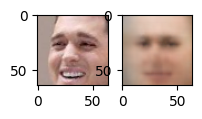

 14%|█▍        | 497/3434 [00:05<00:28, 101.44it/s]

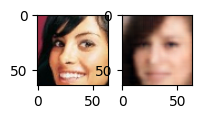

 29%|██▉       | 999/3434 [00:10<00:23, 101.68it/s]

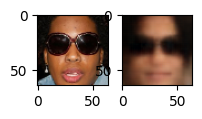

 44%|████▎     | 1496/3434 [00:15<00:19, 98.29it/s] 

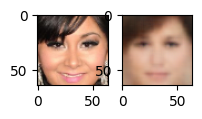

 58%|█████▊    | 1993/3434 [00:20<00:13, 104.08it/s]

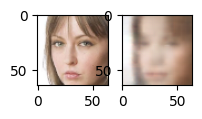

 73%|███████▎  | 2499/3434 [00:25<00:08, 105.48it/s]

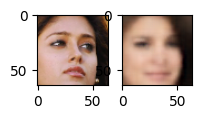

 87%|████████▋ | 2994/3434 [00:30<00:04, 100.56it/s]

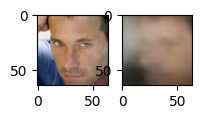

100%|██████████| 3434/3434 [00:35<00:00, 98.06it/s] 
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO: Comet.ml Experiment Summary
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO:   Data:
COMET INFO:     display_summary_level : 1
COMET INFO:     name                  : strong_forest_2482
COMET INFO:     url                   : https://www.comet.com/salvatore-borda/6s191-lab2-part2-dbvae/48988b3e4b06473b972ac90855e4c2b2
COMET INFO:   Metrics [count] (min, max):
COMET INFO:     loss [26442] : (0.04187833517789841, 1.0183733701705933)
COMET INFO:   Parameters:
COMET INFO:     batch_size    : 32
COMET INFO:     latent_dim    : 100
COMET INFO:     learning_rate : 0.0005
COMET INFO:     num_epochs    : 7
COMET INFO:   Uploads:
COMET INFO:     environment details : 1
COMET INFO:     filename            : 1
COMET INFO:     installed packages  : 1
COMET INFO:     model gr

In [24]:
### Training the DB-VAE ###

# Hyperparameters
params = dict(
    batch_size=32,
    learning_rate=5e-4,
    latent_dim=100,
    num_epochs=7,  # DB-VAE needs slightly more epochs to train
)

experiment = create_experiment("debiasing-facial-detection-dbvae", params)

# instantiate a new DB-VAE model and optimizer
dbvae = DB_VAE(params["latent_dim"]).to(device)
optimizer = optim.Adam(dbvae.parameters(), lr=params["learning_rate"])


def debiasing_train_step(x, y):
    optimizer.zero_grad()

    y_logit, z_mean, z_logsigma, x_recon = dbvae(x)
    loss, class_loss = debiasing_loss_function(x, x_recon, y, y_logit, z_mean, z_logsigma)

    loss.backward()
    optimizer.step()

    return loss


# get training faces from data loader
all_faces = loader.get_all_train_faces()

# The training loop -- outer loop iterates over the number of epochs
step = 0
for i in range(params["num_epochs"]):
    IPython.display.clear_output(wait=True)
    print("Starting epoch {}/{}".format(i + 1, params["num_epochs"]))

    # Recompute data sampling proabilities
    p_faces = get_training_sample_probabilities(all_faces, dbvae)

    # get a batch of training data and compute the training step
    for j in tqdm(range(loader.get_train_size() // params["batch_size"])):
        # load a batch of data
        (x, y) = loader.get_batch(params["batch_size"], p_pos=p_faces)
        x = torch.from_numpy(x).float().to(device)
        y = torch.from_numpy(y).float().to(device)

        # loss optimization
        loss = debiasing_train_step(x, y)
        loss_value = loss.detach().cpu().numpy()
        experiment.log_metric("loss", loss_value, step=step)

        # plot the progress every 500 steps
        if j % 500 == 0:
            mdl.util.plot_sample(x, y, dbvae, backend="pt")

        step += 1

experiment.end()

Wonderful! Now we should have a trained and (hopefully!) debiased facial classification model, ready for evaluation!

## Evaluating the DB-VAE

Finally, let's test the DB-VAE on the test dataset, looking specifically at the accuracy on each of the four demographics: "Dark Male", "Dark Female", "Light Male" and "Light Female". We compare the debiased model's performance against the (potentially biased) standard CNN from earlier.

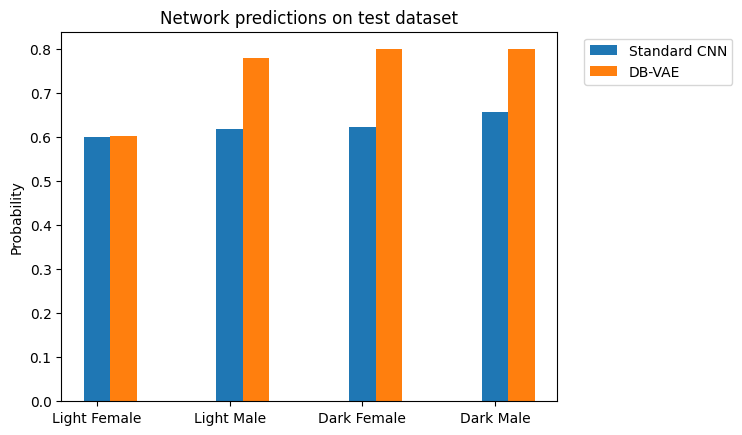

In [25]:
dbvae.to(device)
dbvae_logits_list = []
for face in test_faces:
    face = np.asarray(face, dtype=np.float32)
    face = torch.from_numpy(face).to(device)

    # Forward pass to get the classification logit
    with torch.inference_mode():
        logit = dbvae.predict(face)

    dbvae_logits_list.append(logit.detach().cpu().numpy())

dbvae_logits_array = np.concatenate(dbvae_logits_list, axis=0)
dbvae_logits_tensor = torch.from_numpy(dbvae_logits_array)
dbvae_probs_tensor = torch.sigmoid(dbvae_logits_tensor)
dbvae_probs_array = dbvae_probs_tensor.squeeze(dim=-1).numpy()

xx = np.arange(len(keys))

std_probs_mean = standard_classifier_probs.mean(axis=1)
dbvae_probs_mean = dbvae_probs_array.reshape(len(keys), -1).mean(axis=1)

plt.bar(xx, std_probs_mean, width=0.2, label="Standard CNN")
plt.bar(xx + 0.2, dbvae_probs_mean, width=0.2, label="DB-VAE")

plt.xticks(xx, keys)
plt.title("Network predictions on test dataset")
plt.ylabel("Probability")
plt.legend(bbox_to_anchor=(1.04, 1), loc="upper left")
plt.show()

## Conclusions

This notebook brought together a few key concepts: vision-based tasks, variational autoencoders (VAEs), and algorithmic bias in machine learning.

Some open questions worth reflecting on:

- How does the accuracy of the DB-VAE across the four demographics compare to that of the standard CNN? Is the result surprising in any way?
- Can the performance of the DB-VAE classifier be pushed even further?
- In which applications (facial detection or otherwise) would this kind of debiasing be desirable? Are there applications where debiasing a model may not be wanted?
- Should companies be required to demonstrate that their models, especially for tasks like facial detection, are not biased? If so, how could this be standardized and enforced?
- What other approaches could help address bias, particularly on the training data side?

One last practical note: the performance of the debiased model can vary significantly depending on the initial hyperparameters, so it is worth experimenting.

![Debiasing](https://i.ibb.co/BjLSRMM/ezgif-2-253dfd3f9097.gif)